In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_path = os.path.join(os.getcwd(),"..", "data", "sondeo.xlsx")

df_sondeo = pd.read_excel(file_path)


df_sondeo.head(5)

,ID,Hora de inicio,Hora de finalización,Correo electrónico,ENCUESTADOR,CÓDIGO DE CUADRA,NOMBRE Y APELLIDO DEL VECINO DE LA CUADRA,¿Qué es lo que más le gusta de vivir en Bilbao?,¿Usted se siente orgullo de vivir en Bilbao?,¿Porque?,...,¿Que ha escuchado?,¿Como ve a su vecino actualmente en el trabajo colaborativo?,¿Que tipo de acciones a usted le gustaría participar para reconocer a sus vecinos?,"¿Qué tendría que pasar para usted diga este año ""valio la pena participar"" ?",¿Que transformación en el barrio usted le haría sentir que el barrio cambió de verdad?,¿Usted confia en sus vecinos?,¿POR QUE?,¿Qué diferencias/conflictos se presentan actualmente en su cuadra?,¿Usted participa para resolver conflictos que se presentan en su cuadra?,¿ POR QUE?
0,1,2026-07-03 09:49:55,2026-07-03 09:53:47,anonymous,ESTUDIANTE MINUTO DE DIOS,TO09,Yara Mendoza perez,Tranquila,SI,Transporte,...,Nada,Cada quien en su cuento,JORNADA DE LIMPIEZA EN CUADRA,Apoyar en las cuadras en tema limpiaza,Tema basura,NO,No los conozco,"Temas de basuras ,olores, rodedores",NO,No aplica
1,2,2026-07-03 09:08:08,2026-07-03 09:54:39,anonymous,ESTUDIANTE MINUTO DE DIOS,TO09,María barrera,Le gusta,SI,Es su barrio la partencia,...,Nada,Participaba en la casa de los abuelos,JORNADA DE SENSILIZACION DE MASCOTAS,Los arreglos,Mejoramiento de vecinos,SI,Colaboración,Ninguna,NO,No sé entera en conflictos
2,3,2026-07-03 09:07:35,2026-07-03 09:55:22,anonymous,ESTUDIANTE MINUTO DE DIOS,TO09,Idalia,Transporte,SI,No,...,No,No tenemos comunicación,Ejercicios,NaN,NaN,NO,No los conozco,No se presenta,NO,No
3,4,2026-07-03 10:01:48,2026-07-03 10:05:49,anonymous,ESTUDIANTE MINUTO DE DIOS,TO09,Miguel Ramirez,Todo,SI,Seguridad,...,No aplica,Coloborativos,JORNADA DE LIMPIEZA EN CUADRA,Más orden,Que la gente no bote la basura,NO,No los conoce,Limpieza,SI,Comunicación
4,5,2026-07-03 09:47:15,2026-07-03 10:07:04,anonymous,ESTUDIANTE MINUTO DE DIOS,TO09,ALVARO VERGARA,Por temas familiares,SI,Ninguna,...,No ha escuchado,Inseguridad y no hay trabajo colaborativo,JORNADA DE LIMPIEZA EN CUADRA,No aplica,No aplica,SI,Si con el señor de la esquina y con los del fr...,"Temas de ambiente, de basuras",SI,Cuando hay reuniones de junta comunal


##### ¿Usted se siente orgulloso de vivir en bilbao?

In [19]:

col = df_sondeo["¿Usted se siente orgullo de vivir en Bilbao?\xa0\xa0"].str.strip().str.upper()

def get_porcentaje(tipo:str):
    counter = 0

    for i in col:
        if i == tipo:
            counter += 1


    porcentaje = (counter/len(col))*100
    return round(porcentaje)

per_si = get_porcentaje("SI")
per_no =  get_porcentaje("NO")

print(f"SI: {per_si}%")
print(f"NO: {per_no}%")



SI: 73%
NO: 27%


##### Gráfico

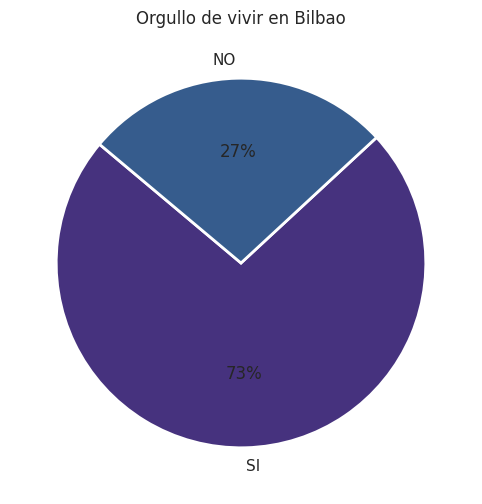

In [15]:
sns.set_theme(style="whitegrid")
paleta = sns.color_palette("viridis")

etiquetas = ["SI", "NO"]
sns.set_theme(style="whitegrid")
valores = [per_si, per_no]

plt.figure(figsize=(8, 6))
plt.pie(valores,
        labels=etiquetas,
        autopct='%1.0f%%',
        colors=paleta,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title("Orgullo de vivir en Bilbao")
plt.show()

##### Differencias y conflictos 

In [21]:
df_sondeo.columns

Index(['ID', 'Hora de inicio', 'Hora de finalización', 'Correo electrónico',
       'ENCUESTADOR', 'CÓDIGO DE CUADRA',
       'NOMBRE Y APELLIDO DEL VECINO DE LA CUADRA',
       '¿Qué es lo que más le gusta de vivir en Bilbao?',
       '¿Usted se siente orgullo de vivir en Bilbao?  ', '¿Porque?',
       '¿Usted ha escuchado de Bilbao, aquí escribes tu historia?',
       '¿Que ha escuchado?',
       '¿Como ve a su vecino actualmente en el trabajo colaborativo?',
       '¿Que tipo de acciones a usted le gustaría participar para reconocer a sus vecinos?',
       '¿Qué tendría que pasar para usted diga este año "valio la pena participar" ?',
       '¿Que transformación en el barrio usted le haría sentir que el barrio cambió de verdad?',
       '¿Usted confia en sus vecinos?', '¿POR QUE? ',
       '¿Qué diferencias/conflictos se presentan actualmente en su cuadra?',
       '¿Usted participa para resolver conflictos que se presentan en su cuadra?',
       '¿ POR QUE? '],
      dtype='str')

/tmp/ipykernel_49932/2538746177.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


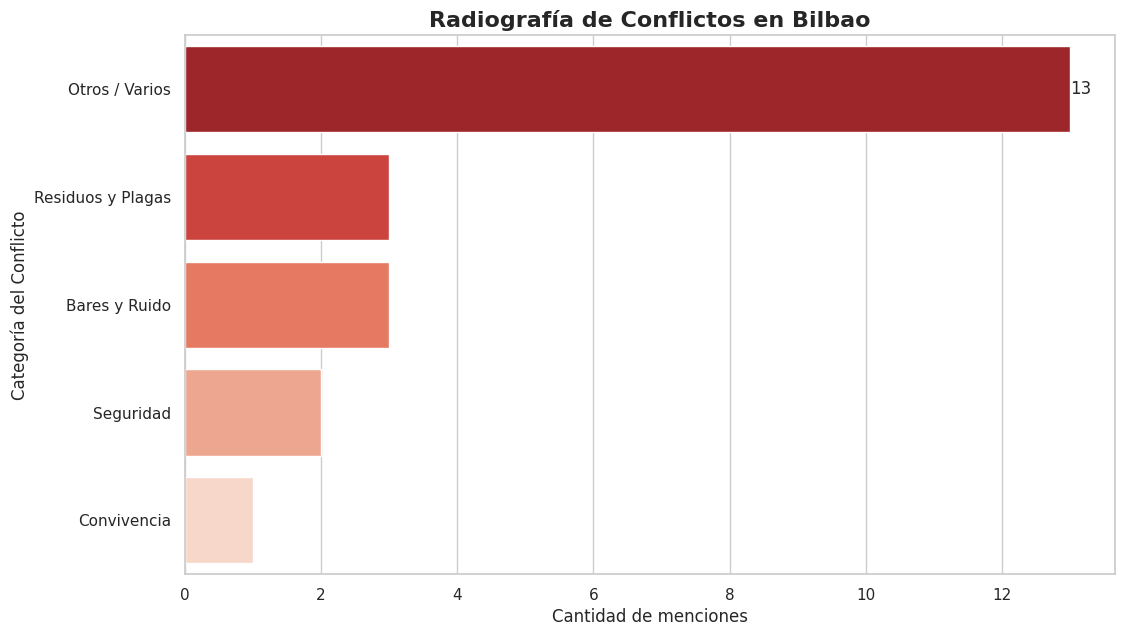

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


categorias_conflictos = {
    'Residuos y Plagas': ['BASURA', 'OLOR', 'ROEDORES', 'RECICLAJE', 'DESECHOS'],
    'Bares y Ruido': ['BAR', 'BORRACHO', 'RUIDO', 'MUSICA', 'FIESTA', 'LICOR'],
    'Seguridad': ['INSEGURIDAD', 'ROBO', 'PELEA', 'ENFRENTAMIENTO', 'DROGA'],
    'Convivencia': ['VECINO', 'CONOZCO', 'COMUNICACIÓN', 'APLICA', 'NADA']
}


def clasificar_texto(texto):
    if pd.isna(texto): return 'Sin Respuesta'
    texto = str(texto).upper()
    for cat, palabras in categorias_conflictos.items():
        if any(p in texto for p in palabras):
            return cat
    return 'Otros / Varios'


col_original = '¿Qué diferencias/conflictos se presentan actualmente en su cuadra?'

df_sondeo['Categoria_Conflicto'] = df_sondeo[col_original].apply(clasificar_texto)


order = df_sondeo['Categoria_Conflicto'].value_counts().index


plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=df_sondeo, 
    y='Categoria_Conflicto', 
    order=order,             
    palette="Reds_r" 
)

ax.bar_label(ax.containers[0])

plt.title('Radiografía de Conflictos en Bilbao', fontsize=16, fontweight='bold')
plt.xlabel('Cantidad de menciones')
plt.ylabel('Categoría del Conflicto')
plt.show()